# TF-IDF + XGBoost Sentiment Classification

This notebook implements a sentiment classification model using TF-IDF vectorization for feature extraction and XGBoost (gradient boosting) for classification. The model is trained on preprocessed sentiment data and evaluated on held-out test data using standard metrics including accuracy, F1 scores, and ROC-AUC curves.

## Imports

In [1]:
import subprocess
subprocess.check_call(['pip', 'install', 'xgboost>=2.0,<3.0', '-q'])

import warnings
warnings.filterwarnings('ignore')

import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, auc, f1_score, accuracy_score
)
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier
import xgboost
import optuna
from optuna.pruners import MedianPruner
import joblib
import os
import io
from io import StringIO
from tqdm import tqdm

sns.set_style('whitegrid')
print(f'xgboost version: {xgboost.__version__}')
print('All imports successful')

xgboost version: 2.1.4
All imports successful


## Helper Classes

In [2]:
class TfidfXgboostModel:
    """
    TF-IDF + XGBoost sentiment classification model.
    
    Combines TF-IDF vectorization with XGBoost gradient boosting for multi-class
    sentiment classification. Includes Optuna-based hyperparameter tuning and
    comprehensive evaluation metrics.
    """
    
    def __init__(self, str_bucket, str_dirname_output):
        self.str_bucket = str_bucket
        self.str_dirname_output = str_dirname_output
        self.cls_tfidf = None
        self.cls_model = None
        self.df_train = None
        self.df_val = None
        self.df_test = None
        self.arr_X_train_tfidf = None
        self.arr_X_val_tfidf = None
        self.arr_X_test_tfidf = None
        self.arr_y_train = None
        self.arr_y_val = None
        self.arr_y_test = None
        self.dict_best_params = None
        self.int_best_n_rounds = None
        self.dict_class_labels = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    
    def import_data(self):
        """Load train, validation, and test data from S3."""
        list_split_names = ['train', 'validation', 'test']
        dict_data = {}
        
        for str_split in list_split_names:
            str_uri = f's3://{self.str_bucket}/02_preprocessing/{str_split}_split.parquet'
            dict_data[str_split] = pd.read_parquet(str_uri)
            print(f'Loaded {str_split} from S3')
        
        self.df_train = dict_data['train']
        self.df_val = dict_data['validation']
        self.df_test = dict_data['test']
        
        self.arr_y_train = self.df_train['sentiment_3class'].values
        self.arr_y_val = self.df_val['sentiment_3class'].values
        self.arr_y_test = self.df_test['sentiment_3class'].values
        
        print(f'Data import complete')
        print(f'  Train: {self.df_train.shape[0]} samples')
        print(f'  Validation: {self.df_val.shape[0]} samples')
        print(f'  Test: {self.df_test.shape[0]} samples')
    
    def build_tfidf(self, int_max_features=3000, tuple_ngram_range=(1, 2)):
        """Build TF-IDF vectorizer and fit on training data."""
        self.cls_tfidf = TfidfVectorizer(
            max_features=int_max_features,
            ngram_range=tuple_ngram_range,
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
        
        self.arr_X_train_tfidf = self.cls_tfidf.fit_transform(self.df_train['review_text_clean'].values)
        self.arr_X_val_tfidf = self.cls_tfidf.transform(self.df_val['review_text_clean'].values)
        self.arr_X_test_tfidf = self.cls_tfidf.transform(self.df_test['review_text_clean'].values)
        
        print(f'TF-IDF vectorizer built')
        print(f'  Features: {self.arr_X_train_tfidf.shape[1]}')
        print(f'  Vocabulary size: {len(self.cls_tfidf.vocabulary_)}')
    
    def tune_model(self, int_n_trials=20):
        """Tune XGBoost hyperparameters using Optuna with early stopping."""
        def objective(trial):
            int_max_depth = trial.suggest_int('max_depth', 3, 10)
            flt_learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
            flt_subsample = trial.suggest_float('subsample', 0.6, 1.0)
            flt_colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0)
            int_min_child_weight = trial.suggest_int('min_child_weight', 1, 10)
            flt_gamma = trial.suggest_float('gamma', 0, 5)
            flt_reg_alpha = trial.suggest_float('reg_alpha', 0, 10)
            flt_reg_lambda = trial.suggest_float('reg_lambda', 0, 10)
            bool_use_class_weight = trial.suggest_categorical('use_class_weight', [True, False])
            
            dict_sample_weight = None
            if bool_use_class_weight:
                from sklearn.utils.class_weight import compute_sample_weight
                dict_sample_weight = compute_sample_weight('balanced', self.arr_y_train)
            
            cls_xgb = XGBClassifier(
                n_estimators=200,
                max_depth=int_max_depth,
                learning_rate=flt_learning_rate,
                subsample=flt_subsample,
                colsample_bytree=flt_colsample_bytree,
                min_child_weight=int_min_child_weight,
                gamma=flt_gamma,
                reg_alpha=flt_reg_alpha,
                reg_lambda=flt_reg_lambda,
                objective='multi:softprob',
                tree_method='hist',
                eval_metric='mlogloss',
                early_stopping_rounds=10,
                random_state=42,
                n_jobs=-1,
                verbosity=0
            )
            
            cls_xgb.fit(
                self.arr_X_train_tfidf,
                self.arr_y_train,
                sample_weight=dict_sample_weight,
                eval_set=[(self.arr_X_val_tfidf, self.arr_y_val)],
                verbose=False
            )
            
            trial.set_user_attr('best_n_rounds', cls_xgb.best_iteration + 1)
            
            arr_y_val_pred = cls_xgb.predict(self.arr_X_val_tfidf)
            flt_f1_macro = f1_score(self.arr_y_val, arr_y_val_pred, average='macro')
            
            return flt_f1_macro
        
        cls_sampler = optuna.samplers.TPESampler(seed=42)
        cls_study = optuna.create_study(
            direction='maximize',
            sampler=cls_sampler
        )
        
        cls_study.optimize(objective, n_trials=int_n_trials, show_progress_bar=True)
        
        self.dict_best_params = cls_study.best_params
        self.int_best_n_rounds = cls_study.best_trial.user_attrs['best_n_rounds']
        
        print(f'Hyperparameter tuning complete')
        print(f'  Best F1-Macro: {cls_study.best_value:.4f}')
        print(f'  Best n_estimators (via early stopping): {self.int_best_n_rounds}')
        print(f'  Best parameters: {self.dict_best_params}')
    
    def train_final_model(self):
        """Train final model with best hyperparameters."""
        dict_sample_weight = None
        if self.dict_best_params.get('use_class_weight', False):
            from sklearn.utils.class_weight import compute_sample_weight
            dict_sample_weight = compute_sample_weight('balanced', self.arr_y_train)
        
        self.cls_model = XGBClassifier(
            n_estimators=self.int_best_n_rounds,
            max_depth=self.dict_best_params['max_depth'],
            learning_rate=self.dict_best_params['learning_rate'],
            subsample=self.dict_best_params['subsample'],
            colsample_bytree=self.dict_best_params['colsample_bytree'],
            min_child_weight=self.dict_best_params['min_child_weight'],
            gamma=self.dict_best_params['gamma'],
            reg_alpha=self.dict_best_params['reg_alpha'],
            reg_lambda=self.dict_best_params['reg_lambda'],
            objective='multi:softprob',
            tree_method='hist',
            eval_metric='mlogloss',
            random_state=42,
            n_jobs=-1,
            verbosity=0
        )
        
        self.cls_model.fit(
            self.arr_X_train_tfidf,
            self.arr_y_train,
            sample_weight=dict_sample_weight
        )
        
        print(f'Final model trained with {self.int_best_n_rounds} rounds')
    
    def evaluate(self):
        """Evaluate model on test set."""
        arr_y_test_pred = self.cls_model.predict(self.arr_X_test_tfidf)
        arr_y_test_proba = self.cls_model.predict_proba(self.arr_X_test_tfidf)
        
        flt_accuracy = accuracy_score(self.arr_y_test, arr_y_test_pred)
        flt_f1_macro = f1_score(self.arr_y_test, arr_y_test_pred, average='macro')
        flt_f1_weighted = f1_score(self.arr_y_test, arr_y_test_pred, average='weighted')
        flt_roc_auc = roc_auc_score(self.arr_y_test, arr_y_test_proba, multi_class='ovr', average='macro')
        
        print(f'Model Evaluation')
        print(f'  Accuracy: {flt_accuracy:.4f}')
        print(f'  F1-Macro: {flt_f1_macro:.4f}')
        print(f'  F1-Weighted: {flt_f1_weighted:.4f}')
        print(f'  ROC-AUC (Macro): {flt_roc_auc:.4f}')
        print(f'\n{classification_report(self.arr_y_test, arr_y_test_pred, target_names=list(self.dict_class_labels.values()))}')
        
        self.plot_confusion_matrix(arr_y_test_pred)
        self.plot_roc_curves(arr_y_test_proba)
        self.plot_feature_importance()
    
    def plot_confusion_matrix(self, arr_y_pred):
        """Plot confusion matrix."""
        arr_cm = confusion_matrix(self.arr_y_test, arr_y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(arr_cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=list(self.dict_class_labels.values()),
                    yticklabels=list(self.dict_class_labels.values()))
        plt.title('Confusion Matrix - XGBoost + TF-IDF')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/confusion_matrix.png', bbox_inches='tight', dpi=150)
        plt.show()
        print(f'Confusion matrix saved')
    
    def plot_roc_curves(self, arr_y_proba):
        """Plot ROC curves for each class."""
        arr_y_bin = label_binarize(self.arr_y_test, classes=[0, 1, 2])
        
        plt.figure(figsize=(10, 8))
        for int_i in range(3):
            arr_fpr, arr_tpr, _ = roc_curve(arr_y_bin[:, int_i], arr_y_proba[:, int_i])
            flt_roc_auc = auc(arr_fpr, arr_tpr)
            plt.plot(arr_fpr, arr_tpr, lw=2, 
                    label=f'{list(self.dict_class_labels.values())[int_i]} (AUC = {flt_roc_auc:.3f})')
        
        plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curves - XGBoost + TF-IDF')
        plt.legend(loc='lower right')
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/roc_curves.png', bbox_inches='tight', dpi=150)
        plt.show()
        print(f'ROC curves saved')
    
    def plot_feature_importance(self, int_top_n=20):
        """Plot top features by gain (XGBoost feature importance)."""
        arr_importance = self.cls_model.feature_importances_
        list_indices = np.argsort(arr_importance)[-int_top_n:]
        list_features = [self.cls_tfidf.get_feature_names_out()[int_idx] for int_idx in list_indices]
        arr_values = arr_importance[list_indices]
        
        plt.figure(figsize=(10, 8))
        plt.barh(range(len(list_features)), arr_values, color='steelblue')
        plt.yticks(range(len(list_features)), list_features)
        plt.xlabel('Feature Importance (Gain)')
        plt.title('Top 20 Features by Gain - XGBoost')
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/feature_importance.png', bbox_inches='tight', dpi=150)
        plt.show()
        print(f'Feature importance plot saved')
    
    def save_model(self):
        """Save model and vectorizer as joblib files."""
        joblib.dump(self.cls_model, f'{self.str_dirname_output}/xgboost_model.pkl')
        joblib.dump(self.cls_tfidf, f'{self.str_dirname_output}/tfidf_vectorizer.pkl')
        print(f'Model and vectorizer saved')

## Constants

In [3]:
str_bucket = 'nlp-sentiment-analysis-demo'
str_task = '05_tfidf_xgboost'
str_dirname_output = './output'
int_tfidf_max_features = 3000
tuple_ngram_range = (1, 1)
int_optuna_trials = 5

print('✓ Constants defined')

✓ Constants defined


## Output Directory

In [4]:
os.makedirs(str_dirname_output, exist_ok=True)
print(f'✓ Output directory ready: {str_dirname_output}')

✓ Output directory ready: ./output


## Load Data and Build Model

In [5]:
cls_model = TfidfXgboostModel(str_bucket, str_dirname_output)
cls_model.import_data()
cls_model.build_tfidf(int_max_features=int_tfidf_max_features, tuple_ngram_range=tuple_ngram_range)

Loaded train from S3
Loaded validation from S3
Loaded test from S3
Data import complete
  Train: 18168 samples
  Validation: 6056 samples
  Test: 6057 samples
TF-IDF vectorizer built
  Features: 3000
  Vocabulary size: 3000


In [6]:
cls_model.tune_model(int_n_trials=int_optuna_trials)

[I 2026-03-22 02:47:55,839] A new study created in memory with name: no-name-479f92e7-3fdf-4c62-a3b6-cc278ddab925


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-03-22 02:49:04,106] Trial 0 finished with value: 0.32699768256854095 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'min_child_weight': 2, 'gamma': 0.7799726016810132, 'reg_alpha': 0.5808361216819946, 'reg_lambda': 8.661761457749352, 'use_class_weight': False}. Best is trial 0 with value: 0.32699768256854095.
[I 2026-03-22 02:51:33,840] Trial 1 finished with value: 0.40880235736455645 and parameters: {'max_depth': 3, 'learning_rate': 0.2708160864249968, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'min_child_weight': 2, 'gamma': 0.9170225492671691, 'reg_alpha': 3.0424224295953772, 'reg_lambda': 5.247564316322379, 'use_class_weight': True}. Best is trial 1 with value: 0.40880235736455645.
[I 2026-03-22 02:55:35,139] Trial 2 finished with value: 0.40154774777787966 and parameters: {'max_depth': 7, 'learning_rate': 0.01607123851203988, 'subsample': 0.716857859

In [7]:
cls_model.train_final_model()

Final model trained with 162 rounds


## Evaluate Model

Model Evaluation
  Accuracy: 0.4534
  F1-Macro: 0.4089
  F1-Weighted: 0.4650
  ROC-AUC (Macro): 0.6203

              precision    recall  f1-score   support

    Negative       0.25      0.50      0.33       830
     Neutral       0.33      0.28      0.30      1899
    Positive       0.65      0.54      0.59      3328

    accuracy                           0.45      6057
   macro avg       0.41      0.44      0.41      6057
weighted avg       0.50      0.45      0.47      6057



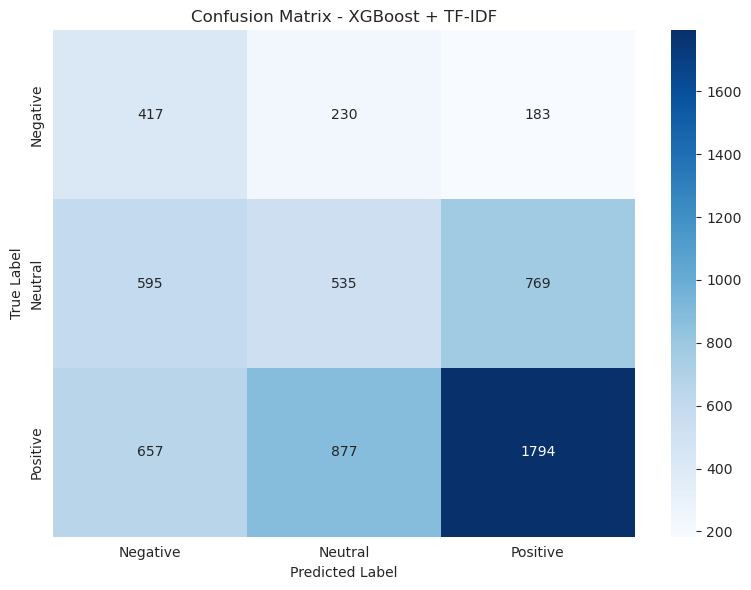

Confusion matrix saved


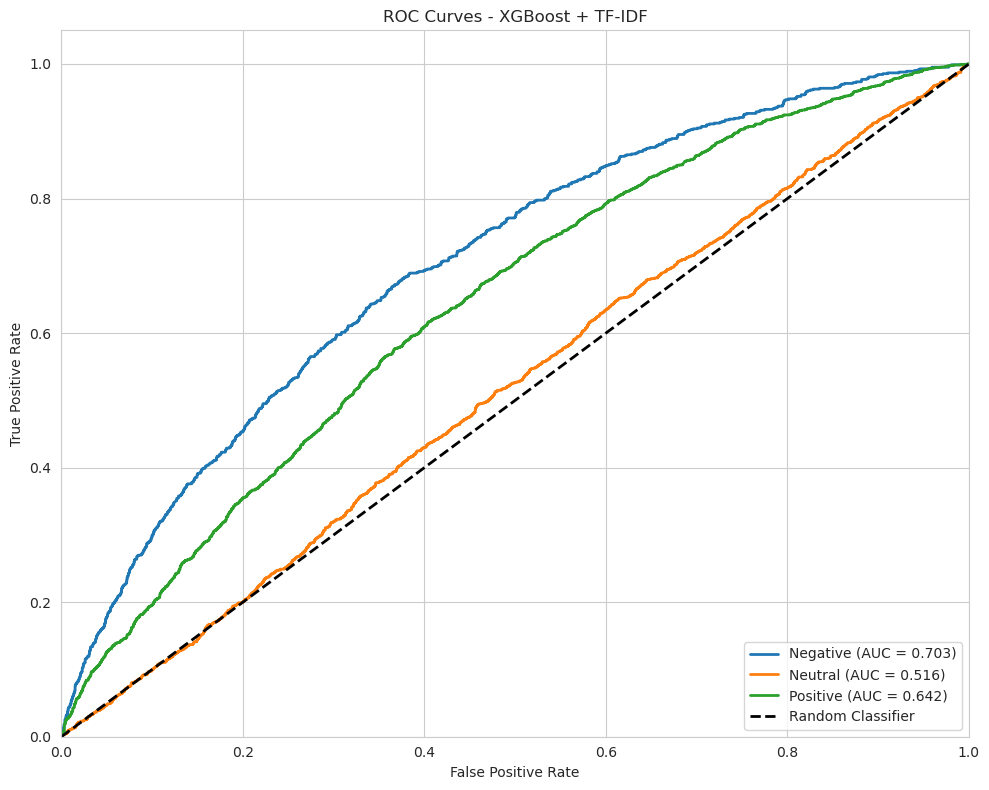

ROC curves saved


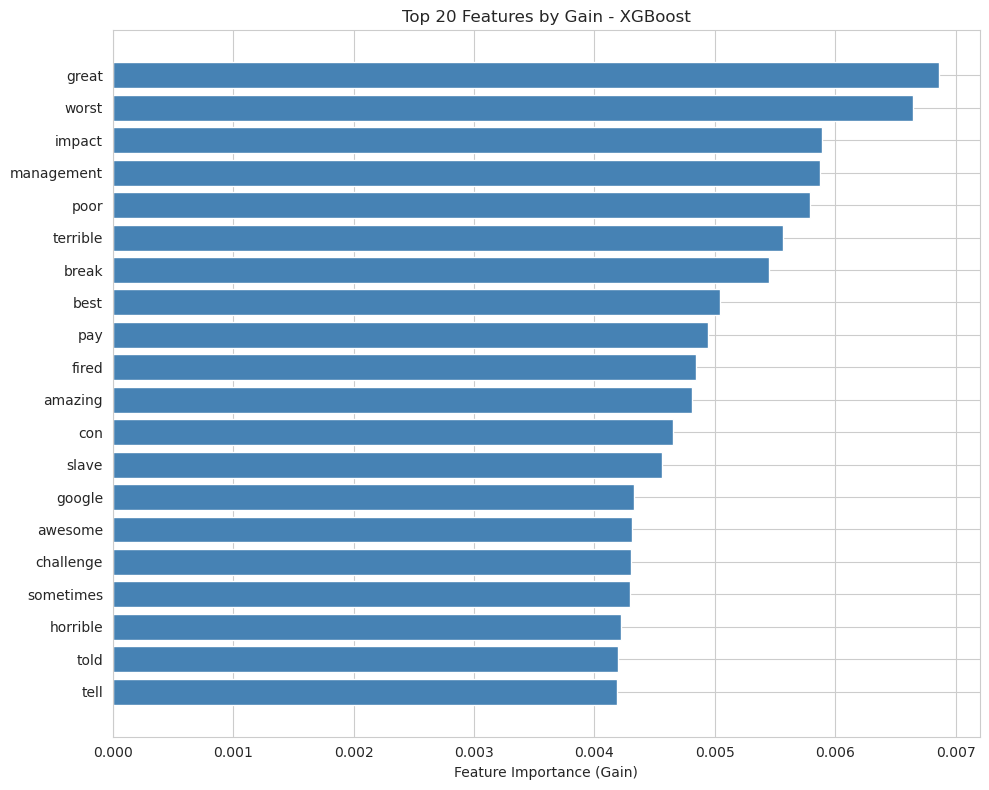

Feature importance plot saved


In [8]:
cls_model.evaluate()

In [9]:
cls_model.save_model()
print(f'\n✓ TF-IDF + XGBoost Sentiment Classification Model Complete')
print(f'  Bucket: {str_bucket}')
print(f'  Output: {str_dirname_output}')
print(f'  Task: {str_task}')

Model and vectorizer saved

✓ TF-IDF + XGBoost Sentiment Classification Model Complete
  Bucket: nlp-sentiment-analysis-demo
  Output: ./output
  Task: 05_tfidf_xgboost
